# Stage 3 Sub-Class Classification
---
In this notebook, training specific XGBoost models to classify the sub-classes for each of the 6 main attack categories: DDoS, DoS, Mirai, Spoofing, Recon, and Web.

To handle the class imbalance and get good performance, using:
- **Feature Engineering**: Adding standard division and multiplication features.
- **BorderlineSMOTE**: To balance out the minority classes before training.
- **Optuna**: For hyperparameter tuning.
- **XGBoost**: For the actual classification, running on GPU to speed things up.

## 1. Imports
loading the necessary libraries and setting up the environment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time, pickle, os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from imblearn.over_sampling import BorderlineSMOTE, SVMSMOTE
from xgboost import XGBClassifier
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.makedirs('models', exist_ok=True)
XGB_DEVICE = 'cuda'
print('Done')

Done


## 2. Load Data
loading the pre-processed Parquet files here. I also need the 34-class label encoder so I can map the numeric classes back to their original string labels. This helps filtering the sub-classes later.

In [2]:
X_train = pd.read_parquet('processed/X_train.parquet')
X_test  = pd.read_parquet('processed/X_test.parquet')
y_train_all = pd.read_parquet('processed/y_train.parquet')
y_test_all  = pd.read_parquet('processed/y_test.parquet')

with open('processed/label_encoders.pkl', 'rb') as f:
    le_34 = pickle.load(f)['le_34']

y_train_all['label'] = le_34.inverse_transform(y_train_all['class_34'])
y_test_all['label']  = le_34.inverse_transform(y_test_all['class_34'])

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (5599989, 39), Test: (1399998, 39)


## 3. Category Map and Feature Engineering

### 3.1 Category Map
This dictionary maps each main attack category to its individual sub-classes.
(Note: BruteForce is excluded because it only has one sub-class, DictionaryBruteForce, so there's nothing to classify once we know it's a BruteForce attack).

In [3]:
# BruteForce has only one sub-class (DictionaryBruteForce) — nothing to classify
CATEGORY_MAP = {
    'DDoS': [
        'DDoS-ICMP_Flood', 'DDoS-UDP_Flood', 'DDoS-TCP_Flood',
        'DDoS-HTTP_Flood', 'DDoS-SlowLoris', 'DDoS-RSTFINFlood',
        'DDoS-PSHACK_Flood', 'DDoS-SYN_Flood', 'DDoS-ACK_Fragmentation',
        'DDoS-UDP_Fragmentation', 'DDoS-ICMP_Fragmentation',
        'DDoS-SynonymousIP_Flood'
    ],
    'DoS':      ['DoS-UDP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-HTTP_Flood'],
    'Mirai':    ['Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain'],
    'Spoofing': ['DNS_Spoofing', 'MITM-ArpSpoofing'],
    'Recon': [
        'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PortScan',
        'VulnerabilityScan', 'Recon-PingSweep'
    ],
    'Web': [
        'BrowserHijacking', 'Backdoor_Malware', 'XSS',
        'Uploading_Attack', 'SqlInjection', 'CommandInjection'
    ],
}

### 3.2 Feature Engineering
adding a simple function to create interaction features between the first few columns. This usually helps XGBoost find better splits.

In [4]:
def add_features(X):
    X    = X.copy()
    cols = X.columns.tolist()
    for i in range(min(5, len(cols))):
        for j in range(i + 1, min(10, len(cols))):
            c1, c2 = cols[i], cols[j]
            X[f'{c1}_div_{c2}'] = X[c1] / (X[c2] + 1e-8)
            X[f'{c1}_mul_{c2}'] = X[c1] * X[c2]
    return X

print('Ready')

Ready


## 4. Train Sub-Class Models
This is the main training logic. Broken down into a few helper functions to keep things clean before running the main loop over all the categories.

### 4.1 Result Storage
Setting up dictionaries to store the metrics and predictions for each category.

In [5]:
all_results = {}
all_preds   = {}

### 4.2 Extract Category Data
This function isolates the data for the specific category we are about to train on, and applies the feature engineering.

In [6]:
def get_category_data(category, sub_labels):
    mask_tr = y_train_all['label'].isin(sub_labels)
    mask_te = y_test_all['label'].isin(sub_labels)

    X_tr_full = add_features(X_train.loc[mask_tr])
    X_te = add_features(X_test.loc[mask_te])
    y_tr_full = y_train_all.loc[mask_tr, 'label'].copy()
    y_te = y_test_all.loc[mask_te, 'label'].copy()

    # Split training into train/validation (80/20) to prevent test-set leakage
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_full, y_tr_full, test_size=0.2, random_state=42, stratify=y_tr_full
    )

    print('  Class distribution (train full):')
    print(y_tr_full.value_counts())

    return X_tr, X_val, X_te, y_tr, y_val, y_te


### 4.3 Encode Labels and Apply BorderlineSMOTE
Since the sub-classes are pretty imbalanced, this function encodes the labels and applies BorderlineSMOTE to give the minority classes a fair chance during training.

In [7]:
def encode_and_resample(X_tr, y_tr):
    le    = LabelEncoder()
    y_enc = le.fit_transform(y_tr)

    min_class = pd.Series(y_enc).value_counts().min()
    k = min(5, min_class - 1)

    smote = BorderlineSMOTE(random_state=42, k_neighbors=k, kind='borderline-1')
    X_res, y_res = smote.fit_resample(X_tr, y_enc)
    X_res = pd.DataFrame(X_res, columns=X_tr.columns)

    print(f'  BorderlineSMOTE: {len(X_tr):,} -> {len(X_res):,} samples')
    return le, X_res, y_res

### 4.4 Optuna Objective Function
This defines the hyperparameter search space for Optuna. The objective is to maximize the Macro F1-Score.

In [8]:
# Defines the hyperparameter search space and trains the model for Optuna to evaluate

def make_objective(X_tr_sm, y_tr_sm, X_val, y_val_enc, sw, n_cls):
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
            'max_depth':        trial.suggest_int('max_depth', 4, 18),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
            'gamma':            trial.suggest_float('gamma', 0, 5),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        }
        model = XGBClassifier(
            objective='multi:softmax', num_class=n_cls,
            eval_metric='mlogloss', early_stopping_rounds=50,
            device=XGB_DEVICE, random_state=42, verbosity=0,
            **params
        )
        model.fit(
            X_tr_sm, y_tr_sm,
            sample_weight=sw,
            eval_set=[(X_val, y_val_enc)],
            verbose=False
        )
        pred = model.predict(X_val)
        return f1_score(y_val_enc, pred, average='macro')

    return objective


### 4.5 Train Final Model
After finding the best parameters with Optuna, use this function to train the final model on the resampled training set.

In [9]:
# Initializes and fits an XGBClassifier using the best parameters found by Optuna

def train_final_model(X_tr_sm, y_tr_sm, X_val, y_val_enc, sw, n_cls, best_params):
    model = XGBClassifier(
        objective='multi:softmax', num_class=n_cls,
        eval_metric='mlogloss', early_stopping_rounds=50,
        device=XGB_DEVICE, random_state=42, verbosity=0,
        **best_params
    )
    model.fit(
        X_tr_sm, y_tr_sm,
        sample_weight=sw,
        eval_set=[(X_val, y_val_enc)],
        verbose=False
    )
    return model


### 4.6 Save Models
A quick utility to save the trained model and its specific label encoder for later use.

In [10]:
# Serializes and saves the final model and label encoder objects to persist their states

def save_model(category, model, le):
    with open(f'models/sub_{category}.pkl', 'wb') as f:
        pickle.dump(model, f)
    with open(f'models/enc_{category}.pkl', 'wb') as f:
        pickle.dump(le, f)
    print(f'  Saved: models/sub_{category}.pkl')

### 4.7 Main Training Loop
Now iterating through CATEGORY_MAP. For each category, run through the pipeline: filtering data, oversampling with SMOTE, tuning with Optuna, and saving the final model.

In [11]:
for category, sub_labels in CATEGORY_MAP.items():

    print(f'\n===== {category} ({len(sub_labels)} classes) =====')

    # step 1 — filter and build features
    X_tr, X_val, X_te, y_tr, y_val, y_te = get_category_data(category, sub_labels)

    # step 2 — encode and balance
    le, X_tr_sm, y_tr_sm = encode_and_resample(X_tr, y_tr)
    y_val_enc = le.transform(y_val)
    y_te_enc = le.transform(y_te)

    # step 3 — sample weights and class count
    sw    = compute_sample_weight('balanced', y_tr_sm)
    n_cls = len(le.classes_)

    # step 4 — hyperparameter search with Optuna
    objective = make_objective(X_tr_sm, y_tr_sm, X_val, y_val_enc, sw, n_cls)
    t0 = time.time()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    train_time = time.time() - t0

    # step 5 — retrain with best params
    best_model = train_final_model(
        X_tr_sm, y_tr_sm, X_val, y_val_enc, sw, n_cls, study.best_params
    )

    # step 6 — evaluate on UNSEEN test set
    y_pred = best_model.predict(X_te)
    f1     = f1_score(y_te_enc, y_pred, average='macro')
    acc    = accuracy_score(y_te_enc, y_pred)
    t_str  = f'{train_time / 60:.1f}m'

    print(f'  F1: {f1:.4f} | Acc: {acc:.4f} | Time: {t_str}')
    print(f'  Best params: {study.best_params}')

    # step 7 — persist
    save_model(category, best_model, le)

    # step 8 — store for reporting
    all_results[category] = {'f1': f1, 'acc': acc, 'time': t_str}
    all_preds[category]   = {
        'y_true': y_te_enc,
        'y_pred': y_pred,
        'labels': list(le.classes_)
    }



===== DDoS (12 classes) =====
  Class distribution (train full):
label
DDoS-ICMP_Flood            636133
DDoS-UDP_Flood             477861
DDoS-TCP_Flood             397181
DDoS-PSHACK_Flood          361677
DDoS-SYN_Flood             357983
DDoS-RSTFINFlood           356487
DDoS-SynonymousIP_Flood    317649
DDoS-ACK_Fragmentation     227930
DDoS-ICMP_Fragmentation     39788
DDoS-UDP_Fragmentation      25274
DDoS-HTTP_Flood             23176
DDoS-SlowLoris              18694
Name: count, dtype: int64
  BorderlineSMOTE: 2,591,866 -> 6,106,872 samples


  0%|          | 0/30 [00:00<?, ?it/s]

  F1: 0.9997 | Acc: 0.9999 | Time: 45.7m
  Best params: {'n_estimators': 607, 'max_depth': 8, 'learning_rate': 0.08376998938690865, 'subsample': 0.6628787048768763, 'colsample_bytree': 0.6477211370636599, 'min_child_weight': 5, 'gamma': 0.005027592515312717, 'reg_alpha': 0.06872264325707969, 'reg_lambda': 0.011417023547988155}
  Saved: models/sub_DDoS.pkl

===== DoS (4 classes) =====
  Class distribution (train full):
label
DoS-UDP_Flood     292843
DoS-TCP_Flood     235850
DoS-SYN_Flood     178530
DoS-HTTP_Flood     57558
Name: count, dtype: int64
  BorderlineSMOTE: 611,824 -> 937,096 samples


  0%|          | 0/30 [00:00<?, ?it/s]

  F1: 1.0000 | Acc: 1.0000 | Time: 3.7m
  Best params: {'n_estimators': 768, 'max_depth': 13, 'learning_rate': 0.12712951225573746, 'subsample': 0.8249811189365384, 'colsample_bytree': 0.3839201166646291, 'min_child_weight': 4, 'gamma': 2.6462166429013836, 'reg_alpha': 0.007613213136325785, 'reg_lambda': 0.042203221221569574}
  Saved: models/sub_DoS.pkl

===== Mirai (3 classes) =====
  Class distribution (train full):
label
Mirai-greeth_flood    87553
Mirai-udpplain        78779
Mirai-greip_flood     66479
Name: count, dtype: int64
  BorderlineSMOTE: 186,248 -> 210,126 samples


...

  F1: 0.9308 | Acc: 0.9649 | Time: 2.3m
  Best params: {'n_estimators': 949, 'max_depth': 8, 'learning_rate': 0.06716138723150332, 'subsample': 0.6473898559550026, 'colsample_bytree': 0.9225099469112297, 'min_child_weight': 3, 'gamma': 0.2578154366830221, 'reg_alpha': 0.07233946132568984, 'reg_lambda': 3.080768101401887}
  Saved: models/sub_Spoofing.pkl

===== Recon (5 classes) =====
  Class distribution (train full):
label
Recon-HostDiscovery    107352
Recon-OSScan            78711
Recon-PortScan          65843
VulnerabilityScan       29869
Recon-PingSweep          1839
Name: count, dtype: int64
  BorderlineSMOTE: 226,891 -> 429,410 samples


  0%|          | 0/30 [00:00<?, ?it/s]

  F1: 0.8686 | Acc: 0.9033 | Time: 8.9m
  Best params: {'n_estimators': 580, 'max_depth': 17, 'learning_rate': 0.07412640124480623, 'subsample': 0.564281517282684, 'colsample_bytree': 0.3770369936519514, 'min_child_weight': 2, 'gamma': 0.22897317226973746, 'reg_alpha': 0.046350778033277654, 'reg_lambda': 3.5506707801391655}
  Saved: models/sub_Recon.pkl

===== Web (6 classes) =====
  Class distribution (train full):
label
BrowserHijacking    4697
CommandInjection    4325
SqlInjection        4205
XSS                 3083
Backdoor_Malware    2576
Uploading_Attack     992
Name: count, dtype: int64
  BorderlineSMOTE: 15,902 -> 22,542 samples


  0%|          | 0/30 [00:00<?, ?it/s]

  F1: 0.7416 | Acc: 0.7750 | Time: 3.8m
  Best params: {'n_estimators': 704, 'max_depth': 13, 'learning_rate': 0.021093807163408664, 'subsample': 0.5966373438943092, 'colsample_bytree': 0.8477474814461426, 'min_child_weight': 5, 'gamma': 0.8598132607448363, 'reg_alpha': 3.024628177779515, 'reg_lambda': 0.1831938934874141}
  Saved: models/sub_Web.pkl


## 5. Classification Reports
Checking the classification report for each category to see how well the models are performing on the test set.

In [12]:
for cat, data in all_preds.items():
    f1_macro = f1_score(data['y_true'], data['y_pred'], average='macro')
    print(f'\n--- {cat} (F1 Macro: {f1_macro:.4f}) ---')
    print(classification_report(
        data['y_true'], data['y_pred'],
        target_names=data['labels']
    ))


--- DDoS (F1 Macro: 0.9997) ---
                         precision    recall  f1-score   support

 DDoS-ACK_Fragmentation       1.00      1.00      1.00     57174
        DDoS-HTTP_Flood       1.00      1.00      1.00      5614
        DDoS-ICMP_Flood       1.00      1.00      1.00    158245
DDoS-ICMP_Fragmentation       1.00      1.00      1.00     10131
      DDoS-PSHACK_Flood       1.00      1.00      1.00     90067
       DDoS-RSTFINFlood       1.00      1.00      1.00     89799
         DDoS-SYN_Flood       1.00      1.00      1.00     89837
         DDoS-SlowLoris       1.00      1.00      1.00      4732
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     79306
         DDoS-TCP_Flood       1.00      1.00      1.00     99013
         DDoS-UDP_Flood       1.00      1.00      1.00    119236
 DDoS-UDP_Fragmentation       1.00      1.00      1.00      6380

               accuracy                           1.00    809534
              macro avg       1.00      1.00      1.00 

## 6. Confusion Matrices
Plotting confusion matrices to get a visual sense of where the models are making mistakes for each category.

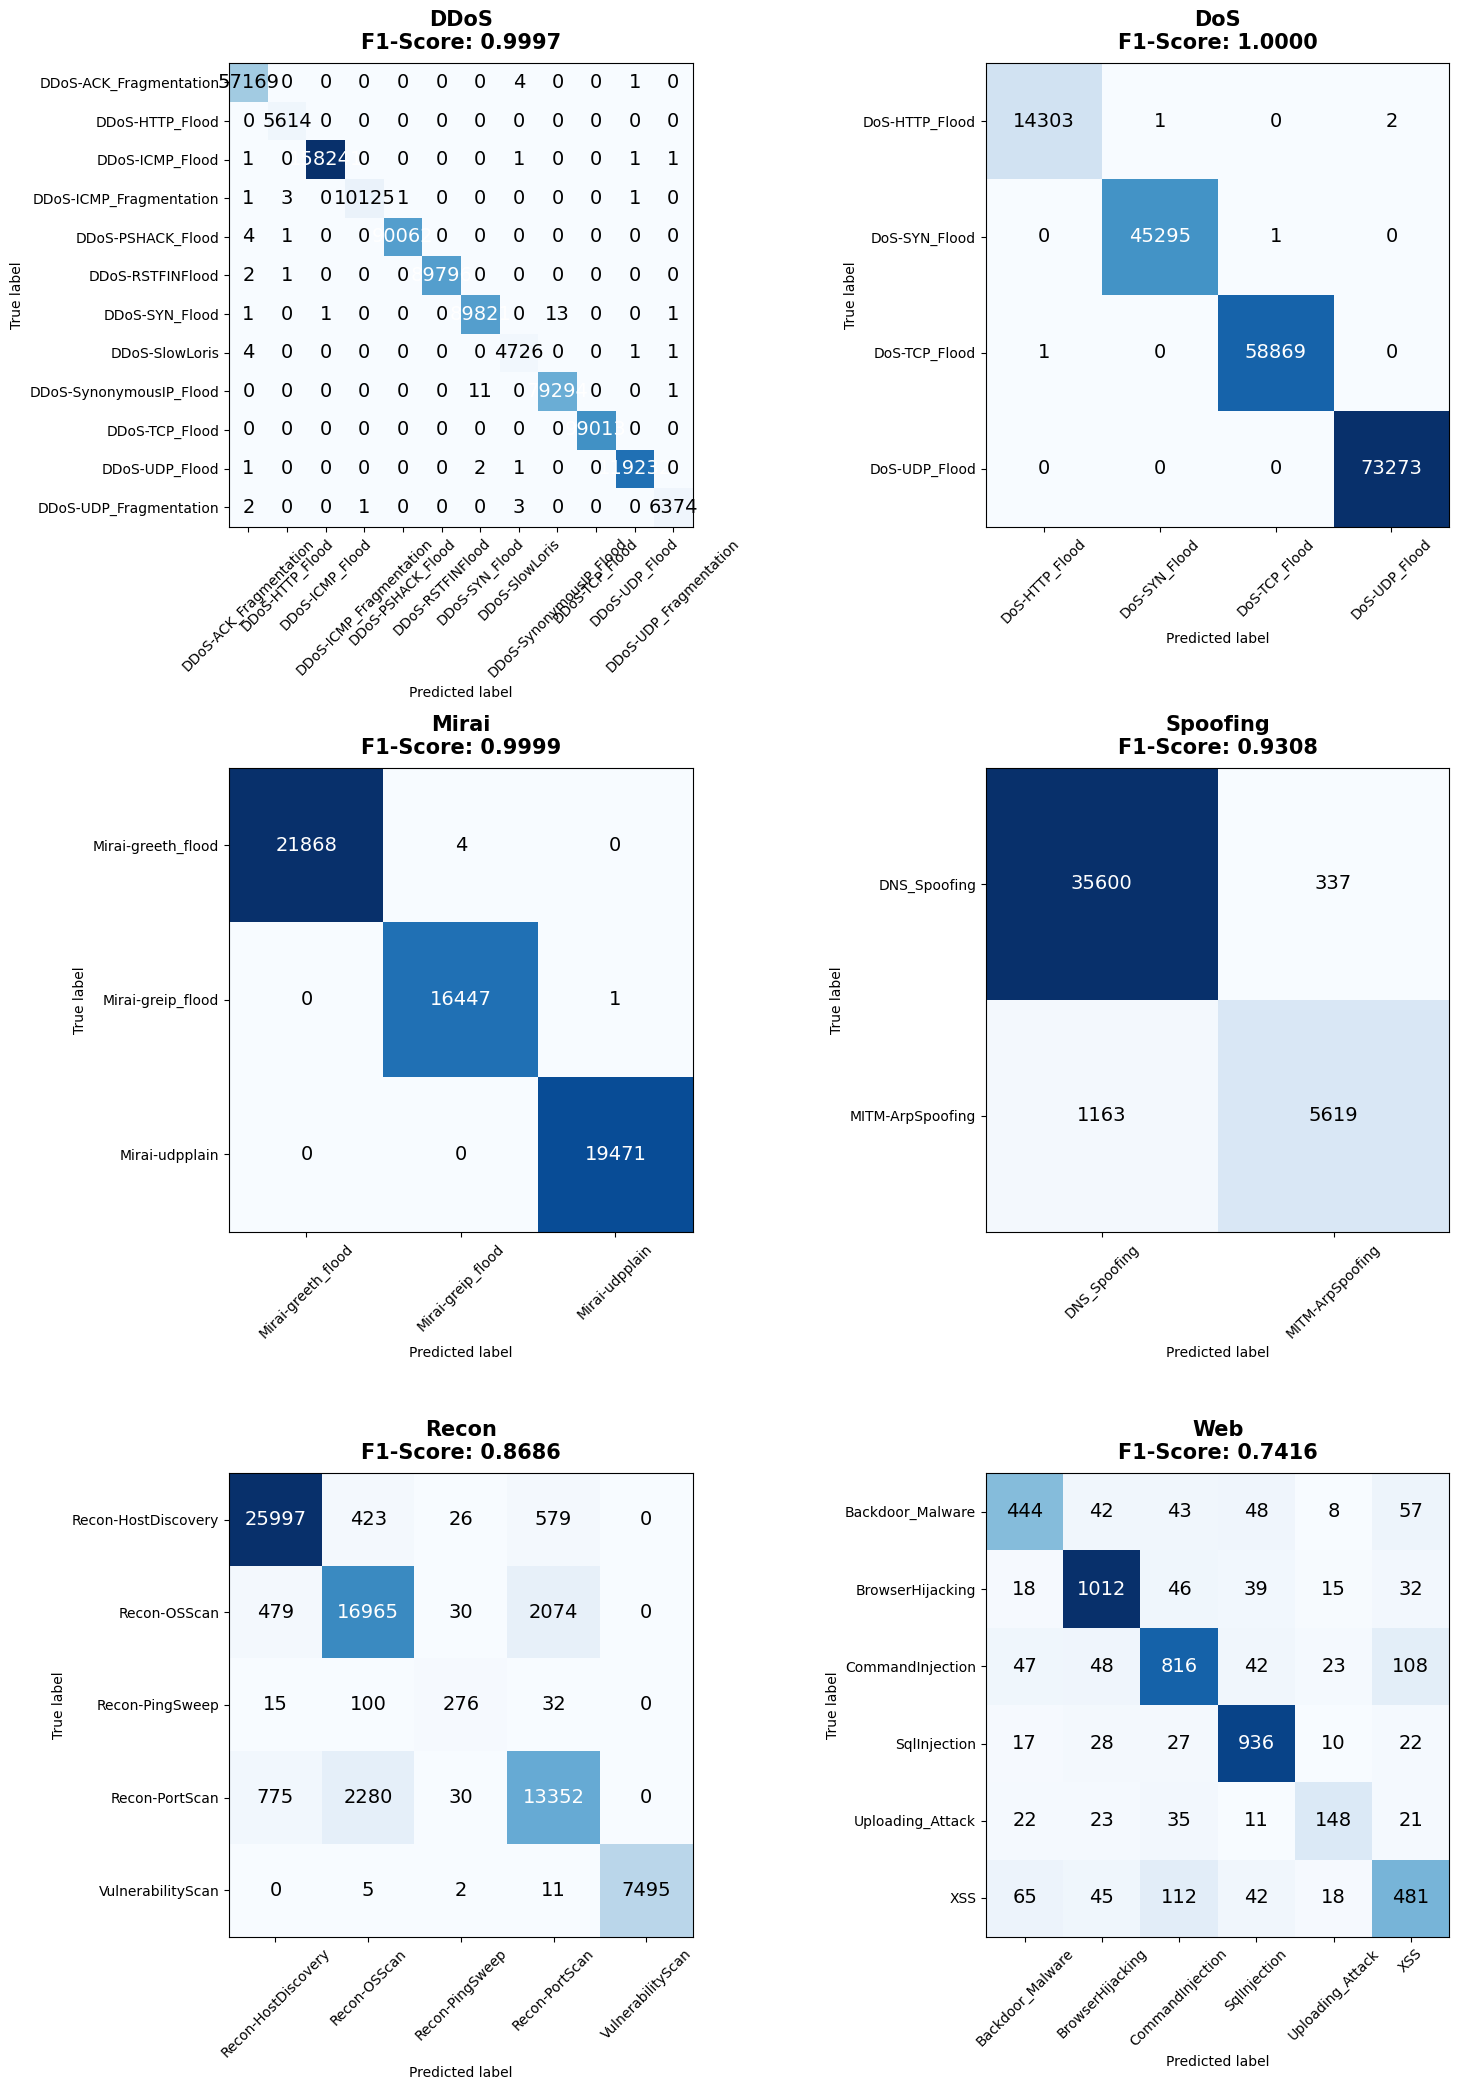

In [13]:
n    = len(all_preds)
cols = 2 
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 7 * rows))
axes = axes.flatten()

for idx, (cat, data) in enumerate(all_preds.items()):
    if idx >= len(axes): break 
    
    f1 = f1_score(data['y_true'], data['y_pred'], average='macro')
    cm = confusion_matrix(data['y_true'], data['y_pred'])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data['labels'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False, xticks_rotation=45, include_values=False)
    
    thresh = cm.max() / 2.0 
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            cell_text = f"{cm[i, j]}"
            axes[idx].text(j, i, cell_text,
                           ha="center", va="center",
                           color="white" if cm[i, j] > thresh else "black",
                           fontsize=14)

    axes[idx].set_title(f"{cat}\nF1-Score: {f1:.4f}", fontsize=15, fontweight='bold', pad=10)

for j in range(len(all_preds), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('models/all_confusion_matrices_6fig.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary
Finally, here is a quick summary of the F1 scores, accuracy, and training time across all models. Also packing everything into single pickle files so it's easier to load them all later for inference.

In [14]:
# Create a DataFrame to summarize results across all categories

summary = pd.DataFrame(all_results).T
summary.index.name = 'Category'
print(summary.to_string())

# Save All Models
import pickle
import os
os.makedirs('models', exist_ok=True)

all_sub_models = {}
all_label_encoders = {}

for cat in CATEGORY_MAP.keys():
        with open(f'models/sub_{cat}.pkl', 'rb') as f:
            all_sub_models[cat] = pickle.load(f)
        with open(f'models/enc_{cat}.pkl', 'rb') as f:
            all_label_encoders[cat] = pickle.load(f)

with open('models/all_sub_models.pkl', 'wb') as f:
    pickle.dump(all_sub_models, f)

with open('models/all_label_encoders.pkl', 'wb') as f:
    pickle.dump(all_label_encoders, f)

with open('models/all_results_and_preds.pkl', 'wb') as f:
    pickle.dump({'results': all_results, 'preds': all_preds}, f)

print("Successfully saved all sub-classification models, encoders, and results into consolidated .pkl files in the 'models/' directory.")


                f1       acc   time
Category                           
DDoS      0.999687  0.999917  45.7m
DoS       0.999952  0.999974   3.7m
Mirai      0.99991  0.999913   1.4m
Spoofing  0.930805  0.964887   2.3m
Recon     0.868566  0.903293   8.9m
Web       0.741588  0.774995   3.8m
Successfully saved all sub-classification models, encoders, and results into consolidated .pkl files in the 'models/' directory.
